# Task 3

## Contribution Breakdown

Team Members:
- Lukas Kurz (K12007739)
- Shamekh Al-Suwi (K12146739)
- Tobias Washüttl (K11916576)
- Daniel Buchberger (K0885317)

_Note: We made use of AI assistance/LLMs for parts of the code to organize, clean up and help with documenting it for easier readability, as is standard practice nowadays. This does not in any way mean that code was plagiarized or copied, unless explicitly stated. All work was done in best conscience by the contributors named above._


## Goal

The primary goal of this project is to perform 3D localization for a simulated car within a known environment. This involves using point cloud data obtained from the car's lidar sensor and aligning it with a pre-existing point cloud map (`map.pcd`) of the environment. The objective is to track the car's pose (position and orientation) as it moves, ensuring the lateral localization error remains below 1.2 meters while covering a significant distance (at least 170m).

## Dataset

The project utilizes a dataset consisting of:
*   **Map:** A point cloud map of the environment (`map.pcd`).
*   **Lidar Scans:** Sequential point clouds captured by the car's lidar (`frame_*.pcd`).
*   **Ground Truth:** The true position and orientation of the car for each frame (`ground_truth.csv`), used for evaluation.

The data was extracted from a simulated car with LiDAR sensors using CARLA simulator.

## Subtasks

The project is divided into two main localization subtasks, followed by an analysis:

### 1. Task 3 - ICP Localization (`task3_icp.ipynb`)

*   **Algorithm:** Iterative Closest Point (ICP).
*   **Objective:** Implement and evaluate ICP for localizing the car by registering the lidar scans to the map.
*   **Key Steps:**
    *   Load the map and frame data.
    *   Initialize the car's pose (e.g., using the first ground truth frame).
    *   Iterate through lidar scan frames.
    *   Downsample the map and scan point clouds (e.g., using a Voxel Grid filter) to manage complexity.
    *   Apply the ICP algorithm (`tools/ICP.py`) to find the rigid transformation (rotation and translation) that best aligns the current (downsampled) scan to the (downsampled) map, relative to the previous pose estimate.
    *   Update the car's estimated pose based on the ICP transformation.
    *   Calculate performance metrics: lateral error, norm error, and computation time per frame.
    *   Visualize the estimated trajectory against the ground truth and analyze the error plots.
*   **Target:** Achieve a maximum lateral error below 1.2 meters.

### 2. Task 3 - NDT Localization (`task3_ndt.ipynb`)

*   **Algorithm:** Normal Distributions Transform (NDT).
*   **Objective:** Implement and evaluate NDT for localizing the car by registering the lidar scans to the map.
*   **Key Steps:**
    *   Load the map and frame data.
    *   Initialize the car's pose.
    *   Represent the map as an NDT grid (`tools/ndt_tools.py`), where each cell contains the mean and covariance of the points within it.
    *   Iterate through lidar scan frames.
    *   Downsample the scan point clouds (e.g., using Voxel Grid and potentially boundary extraction).
    *   Apply the NDT algorithm to find the pose that maximizes the likelihood of the scan points falling onto the NDT map's probability distributions. This involves optimization techniques (like Newton's method).
    *   Update the car's estimated pose.
    *   Calculate performance metrics: lateral error, yaw error, and computation time per frame. This notebook also includes parameter tuning and grid search capabilities.
    *   Visualize the estimated trajectory against the ground truth and analyze the error plots.
*   **Target:** Achieve a maximum lateral error below 1.2 meters.

### 3. Analysis

*   Compare the performance, robustness, computational complexity, and parameter sensitivity of the ICP and NDT localization methods based on the results obtained in the previous subtasks.
*   Analyze error trends, maximum errors, and computation times for both algorithms.


## Setup



### Environment Separation

To get all the necessary dependencies we recommend creating a seperate python environment either using venv or conda, so that you do not mess up your base python installation.

Example for creating and activating a conda environment:

```bash
conda create -n autonomous_driving python=3.8
conda activate autonomous_driving
```


Example for creating and activating a venv environment:

```bash
python -m venv autonomous_driving
source autonomous_driving/bin/activate  # On Linux/Mac
```

There are two ways to install the required dependencies for this project:

### Option 1: Direct Installation with Pip

Run the following command in your terminal to install all necessary libraries directly:

```bash
pip install matplotlib numpy pypcd4 scipy pandas opencv-python open3d ipywidgets tqdm ipython
```

### Option 2: Using requirements.txt

1.  Run the following command in your terminal from the project's root directory:

    ```bash
    pip install -r requirements.txt
    ```

Choose either option to set up your environment. We recommend the pip install, since that is more version agnostic than the `requirements.txt`, since that is just a `pip freeze` output of a working environment on our machines.

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time
from tqdm.notebook import tqdm
from itertools import product

from tools.pcd_tools import downsample_voxel, pcd_from_path, boundaries
from tools.plot_tools import plot_pcd, show_pcl, view_frames, plot_map_and_trajectories
from tools.analysis_tools import calc_error
from tools.ICP import ICP, rigid_transformation, calculate_centroid
from tools.dataset import FrameDataset
from tools.ndt_tools import NDT, Pose

For the dataset, we recommend downloading the zip and extracting it in the task3 folder directly, such that the path to a frame would look like `task3/dataset/frames/frame_{frame_number}.pcd

In [4]:
# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

## Dataset

The dataset consists of a sequence of LiDAR point cloud frames, each stored as a .pcd file located in the dataset/frames directory. It also includes a reference point cloud map (dataset/map.pcd). A corresponding ground_truth.csv file provides the accurate 3D position (x, y, z) and orientation (roll, pitch, yaw) for the vehicle at the time each frame was captured. The FrameDataset helper class loads this data, allowing iteration through each frame to retrieve its point cloud and associated ground truth pose. The dataset can optionally be loaded in a 2D configuration, where Z-coordinates for points and poses, as well as roll and pitch angles, are set to zero.

In [5]:
dataset = FrameDataset(FRAMES_DIR, GT_PATH)
map_pcd = pcd_from_path(MAP_PATH)
print(f"Number of frames: {len(dataset)}")

# Get the first frame
pcd, gt_pos, gt_orientation = dataset[0]

Number of frames: 1014


Here we have an interactive display of all the frames, to better see what we are working with.

In [6]:
view_frames([dataset[i][0] for i in range(len(dataset))])

## ICP

This Python function implements a localization pipeline using the Iterative Closest Point (ICP) algorithm to estimate the trajectory of a vehicle based on sequential LiDAR scans and a pre-existing map.

**Purpose:**

To track the 3D pose (position and orientation) of a vehicle over a sequence of LiDAR frames by registering each frame's point cloud to a static map point cloud using ICP.

**Arguments:**

*   `dataset`: An instance of `FrameDataset` which provides access to sequential LiDAR point clouds (`pcd`) and their corresponding ground truth poses (`gt_pos`, `gt_orientation`).
*   `map_pcd`: A NumPy array representing the point cloud of the environment map.
*   `params`: A dictionary containing hyperparameters for the localization process:
    *   `voxel_size` (float): The size of the voxels used for downsampling both the map and the scan point clouds. Default: `0.25`.
    *   `max_frames` (int): The maximum number of frames from the dataset to process. Default: `1500`.
    *   `max_iterations` (int): The maximum number of iterations for the ICP algorithm per frame. Default: `100`.
    *   `max_dist` (float): The maximum distance threshold for point correspondences in ICP. Default: `5.0`.
    *   `tol` (float): The convergence tolerance for the ICP algorithm. Default: `1e-6`.
*   `run_id`: An identifier (e.g., an integer) for this specific execution run, primarily used for labeling the progress bar.

**Returns:**

*   A dictionary containing the results of the localization:
    *   `'gt_positions'` (np.ndarray): An array of the ground truth positions for each processed frame (shape `(N, 3)`).
    *   `'estimated_positions'` (np.ndarray): An array of the estimated positions calculated by the ICP pipeline (shape `(N, 3)`).
    *   `'position_errors'` (np.ndarray): An array of the Euclidean distance (norm) errors between the estimated and ground truth positions for each frame (shape `(N,)`).
    *   `'lateral_errors'` (np.ndarray): An array of the lateral (cross-track) errors for each frame (shape `(N,)`).
    *   `'yaw_errors'` (np.ndarray): An array of the yaw angle errors (in radians) for each frame (shape `(N,)`).
    *   `'computation_times'` (np.ndarray): An array of the computation time (in seconds) taken to process each frame (shape `(N,)`).

**Workflow:**

1.  **Initialization:**
    *   Extracts parameters from the `params` dictionary.
    *   Determines the actual number of frames to process (`num_frames`).
    *   Initializes empty lists to store ground truth positions, estimated positions, errors, and computation times.
    *   Initializes `current_transformation` as a 4x4 identity matrix. This matrix represents the estimated pose of the vehicle in the map frame and is updated iteratively.
    *   Retrieves the ground truth pose (position and orientation) of the *first* frame (`dataset[0]`).
    *   Uses this initial ground truth pose to set the starting value for `current_transformation`. This anchors the localization process.

2.  **ICP Setup:**
    *   Creates an instance of the `ICP` class (from `tools.ICP`) using the specified `max_iterations`, `max_dist`, and `tol`.
    *   Downsamples the `map_pcd` using `downsample_voxel` with the given `voxel_size`. This is done only *once* outside the loop for efficiency.

3.  **Frame-by-Frame Processing Loop:**
    *   Iterates through the dataset frames, starting from the *second* frame (index 1) up to `num_frames`. A `tqdm` progress bar displays the progress.
    *   For each frame `i`:
        *   Retrieves the point cloud `pcd` and ground truth pose (`gt_pos`, `gt_orientation`).
        *   Stores `gt_pos`.
        *   Starts a timer (`time.time()`).
        *   **Downsamples** the current frame's `pcd` using `downsample_voxel`.
        *   **Transforms Scan:** Applies the `current_transformation` (representing the pose estimate *before* processing this frame) to the downsampled scan points (`pcd_voxel`). This step brings the current scan into the global map frame based on the previous estimate.
        *   **ICP Alignment:** Calls the `icp.align()` method to find the relative transformation (rotation `R` and translation `t`) that best aligns the *transformed* `pcd_voxel` (current scan) to the `map_pcd_voxel` (downsampled map).
        *   **Update Pose:** Creates a 4x4 transformation matrix (`icp_transform`) from the relative `R` and `t` returned by ICP. Updates the overall vehicle pose estimate by pre-multiplying the `current_transformation` with this `icp_transform`: `current_transformation = icp_transform @ current_transformation`.
        *   **Extract Results:** Extracts the estimated position (`current_position`) and orientation (`current_orientation`) from the updated `current_transformation`.
        *   Stores `current_position`.
        *   **Calculate Errors:**
            *   Computes the Euclidean distance between `current_position` and `gt_pos` (`position_error`).
            *   Computes the lateral and yaw errors using the `calc_error` utility function.
            *   Stores these errors and updates the maximum observed lateral error.
        *   Calculates the `execution_time` for the frame.
        *   Stores the computation time.
        *   Updates the `tqdm` progress bar's postfix with the calculated errors and time.

In [21]:
def run_icp_localization(dataset, map_pcd, params, run_id):
    """
    Run ICP-based localization on a dataset of point cloud frames.
    
    Args:
        dataset: FrameDataset object containing point cloud frames and ground truth
        map_pcd: Point cloud of the map
        params: Dictionary of parameters including:
            - voxel_size: Size of voxels for downsampling
            - max_frames: Maximum number of frames to process
            - max_iterations: Maximum iterations for ICP
            - max_dist: Maximum distance for correspondence in ICP
            - tol: Convergence tolerance for ICP
        run_id: Identifier for this run (for logging/tracking purposes)
    
    Returns:
        Dictionary containing results:
            - gt_positions: Ground truth positions
            - estimated_positions: Estimated positions
            - position_errors: Position errors
            - computation_times: Computation times
    """
    # Extract parameters
    voxel_size = params.get('voxel_size', 0.25)
    max_frames = params.get('max_frames', 1500)
    max_iterations = params.get('max_iterations', 100)
    max_dist = params.get('max_dist', 5.0)
    tol = params.get('tol', 1e-6)
    
    # Determine number of frames to process
    num_frames = min(len(dataset), max_frames)

    # Lists to track results
    gt_positions = []
    estimated_positions = []
    position_errors = []
    lateral_errors = []
    yaw_errors = []
    computation_times = []
    max_lateral_error = 0

    # Initialize transformation matrix (identity matrix)
    # This will keep track of our current position and orientation
    current_transformation = np.eye(4)

    # Get the initial pose from ground truth to initialize
    init_pcd, init_pos, init_orientation = dataset[0]
    init_rot = Rotation.from_euler('xyz', init_orientation, degrees=False).as_matrix()

    # Initialize with first ground truth position
    init_transform = np.eye(4)
    init_transform[:3, :3] = init_rot
    init_transform[:3, 3] = init_pos
    current_transformation = init_transform

    # Process frames
    pbar = tqdm(range(1, num_frames), desc=f"Processing frames (Run {run_id})", leave=True)

    # Create ICP object
    icp = ICP(max_iterations=max_iterations, max_dist=max_dist, tol=tol)

    # Downsample map once
    map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size)

    for i in pbar:
        # Get the current frame
        pcd, gt_pos, gt_orientation = dataset[i]
        
        # Store ground truth position
        gt_positions.append(gt_pos)
        
        # Voxelize the point clouds to reduce complexity
        start_time = time.time()
        pcd_voxel, _ = downsample_voxel(pcd, voxel_size)
        
        # Create homogeneous coordinates (Nx4)
        homogeneous_points = np.hstack((pcd_voxel, np.ones((pcd_voxel.shape[0], 1))))
        # Apply transformation
        transformed_points = np.dot(homogeneous_points, current_transformation.T)
        # Convert back to 3D points
        pcd_voxel = transformed_points[:, :3]
        
        # Run ICP to align current scan with map
        R, t, _, _, _ = icp.align(pcd_voxel, map_pcd_voxel)
        
        # Create transformation matrix from ICP result
        icp_transform = np.eye(4)
        icp_transform[:3, :3] = R
        # Fix the shape issue - reshape t to be 1D if it's a column vector
        if t.ndim > 1:  # If t is 2D (like shape (3,1))
            t = t.flatten()  # Convert to 1D array
        icp_transform[:3, 3] = t
        
        # Update the current transformation with the ICP result
        current_transformation = np.matmul(icp_transform, current_transformation)
        
        # Extract current position from transformation matrix
        current_position = current_transformation[:3, 3]
        current_orientation = Rotation.from_matrix(current_transformation[:3, :3]).as_euler('xyz', degrees=False)
        
        # Store estimated position
        estimated_positions.append(current_position)
        
        # Compute error
        position_error = np.linalg.norm(current_position - gt_pos)
        lateral_error, yaw_error = calc_error(gt_pos, gt_orientation, current_position, current_orientation)
        position_errors.append(position_error)
        lateral_errors.append(lateral_error)
        yaw_errors.append(yaw_error)
        max_lateral_error = max(max_lateral_error, lateral_error)
        
        # Compute execution time
        execution_time = time.time() - start_time
        computation_times.append(execution_time)
        
        # Update progress bar with current error
        pbar.set_postfix({"Position Error": f"{position_error:.2f}m", "Lateral Error": f"{lateral_error:.2f}m", "Yaw Error": f"{yaw_error:.2f}rad", "Time": f"{execution_time:.2f}s", "Max Lateral Error": f"{max_lateral_error:.2f}m"})

    # Convert lists to numpy arrays
    results = {
        'gt_positions': np.array(gt_positions),
        'estimated_positions': np.array(estimated_positions),
        'position_errors': np.array(position_errors),
        'lateral_errors': np.array(lateral_errors),
        'yaw_errors': np.array(yaw_errors),
        'computation_times': np.array(computation_times)
    }
    
    return results

In [22]:
params = {
    'voxel_size': 0.25,
    'max_frames': 1500,
    'max_iterations': 100,
    'max_dist': 5.0,
    'tol': 1e-6
}

results_icp = run_icp_localization(dataset, map_pcd, params, run_id=1)


Processing frames (Run 1):   0%|          | 0/1013 [00:00<?, ?it/s]

### Analysis

In [25]:
def plot_results(results):
    gt_positions = results['gt_positions']
    estimated_positions = results['estimated_positions']
    computation_times = results['computation_times']
    lateral_errors = results['lateral_errors']
    yaw_errors = results['yaw_errors']
    norm_errors = results['position_errors']

    # Convert lists to numpy arrays
    gt_positions = np.array(gt_positions)
    estimated_positions = np.array(estimated_positions)
    computation_times = np.array(computation_times)
    lateral_errors = np.array(lateral_errors)
    yaw_errors = np.array(yaw_errors)

    max_lateral_error = np.max(lateral_errors)
    max_norm_error = np.max(norm_errors)

    # Plot results
    plt.figure(figsize=(12, 8))

    # Plot lateral and norm error over frames in the same plot
    plt.plot(lateral_errors, label='Lateral Error')
    plt.plot(norm_errors, label='Norm Error', color='orange')
    plt.axhline(y=1.2, color='r', linestyle='--', label='Max allowed error (1.2m)')

    # Mark the position of the max lateral error
    max_error_index = np.argmax(lateral_errors)
    plt.scatter(max_error_index, max_lateral_error, color='red', s=100, label=f'Max Lateral Error: {max_lateral_error:.2f} m')
    plt.text(max_error_index, max_lateral_error, f'{max_lateral_error:.2f} m', fontsize=9, ha='right')

    # Mark the position of the max norm error
    max_error_index = np.argmax(norm_errors)
    plt.scatter(max_error_index, max_norm_error, color='blue', s=100, label=f'Max Norm Error: {max_norm_error:.2f} m')
    plt.text(max_error_index, max_norm_error, f'{max_norm_error:.2f} m', fontsize=9, ha='right')

    plt.title("Lateral and Norm Error over Frames")
    plt.xlabel("Frame")
    plt.ylabel("Error (meters)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Calculate cumulative errors
    cumulative_lateral_errors = np.cumsum(lateral_errors)
    cumulative_norm_errors = np.cumsum(np.linalg.norm(estimated_positions - gt_positions, axis=1))

    # Plot cumulative lateral and norm errors in one plot
    plt.figure(figsize=(12, 8))
    plt.plot(cumulative_lateral_errors, label='Cumulative Lateral Error')
    plt.plot(cumulative_norm_errors, label='Cumulative Norm Error', color='orange')
    plt.title("Cumulative Errors over Frames")
    plt.xlabel("Frame")
    plt.ylabel("Cumulative Error (meters)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Plot computation times across frames
    plt.figure(figsize=(12, 8))
    plt.plot(computation_times, label='Computation Time', color='purple')
    plt.title("Computation Times over Frames")
    plt.xlabel("Frame")
    plt.ylabel("Time (seconds)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plot_map_and_trajectories(map_pcd, gt_positions, estimated_positions)

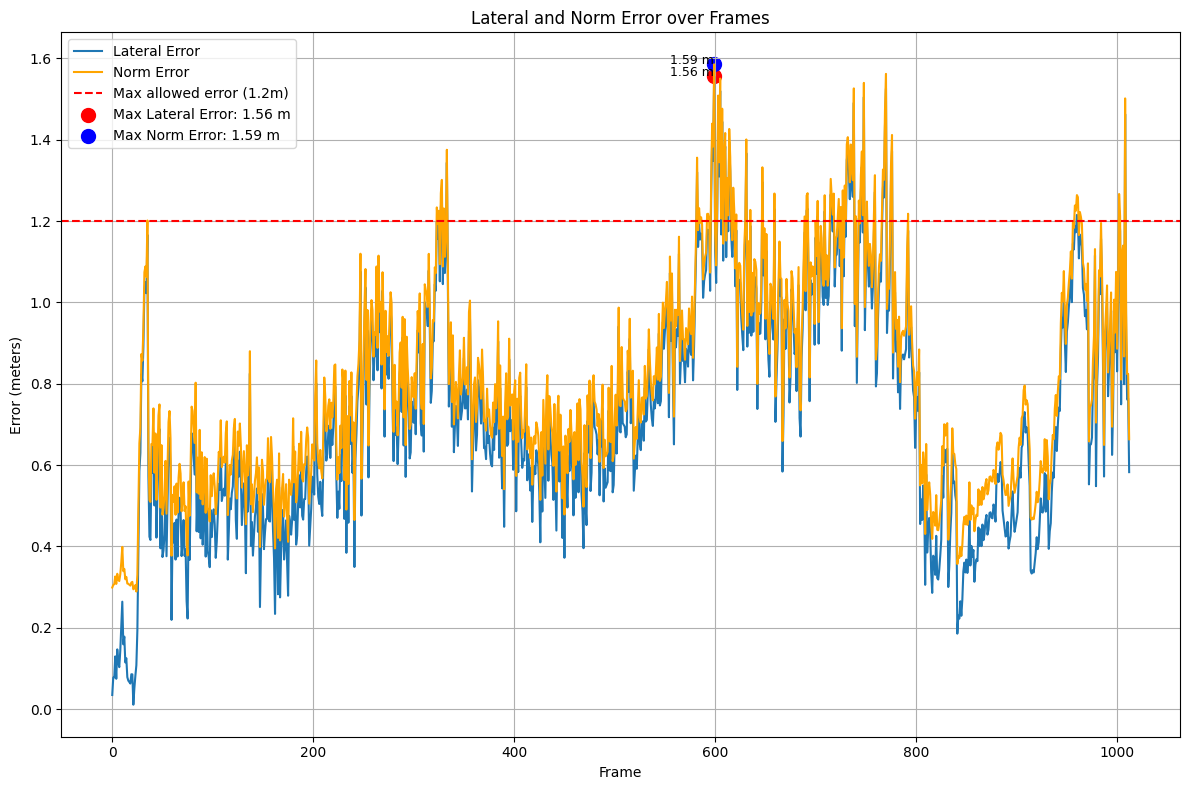

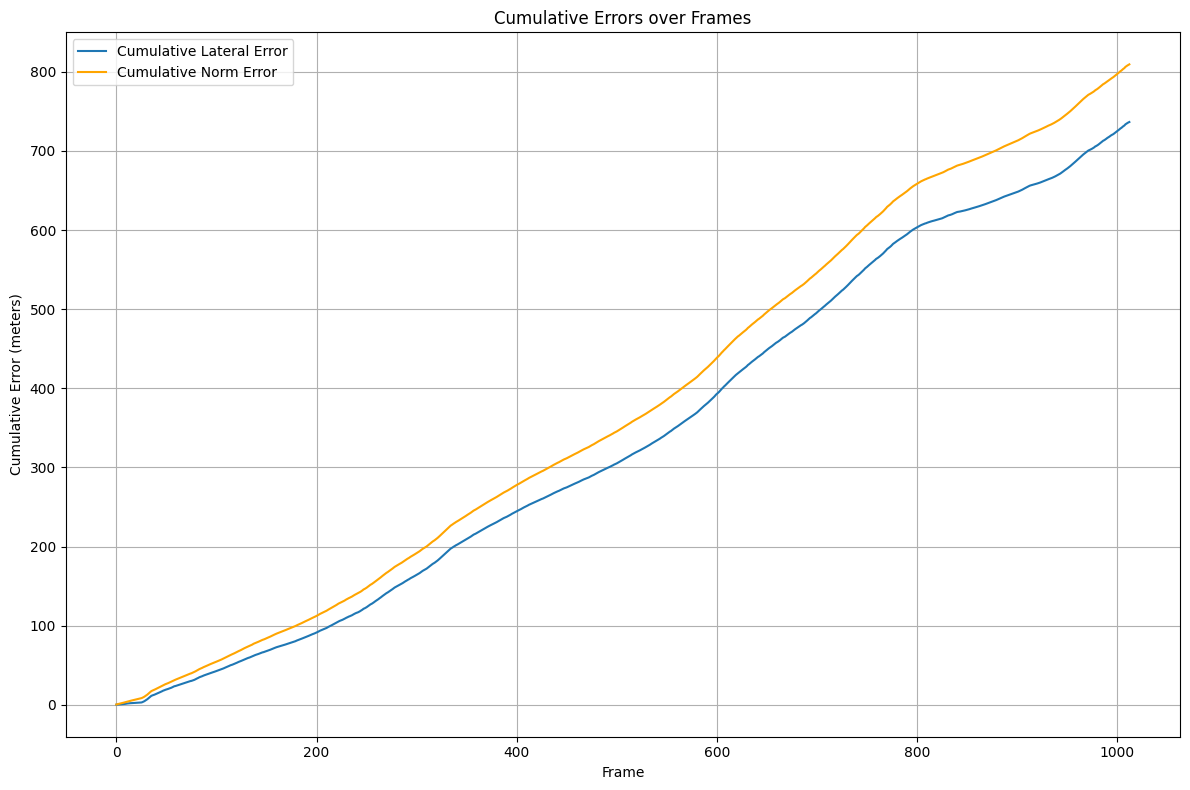

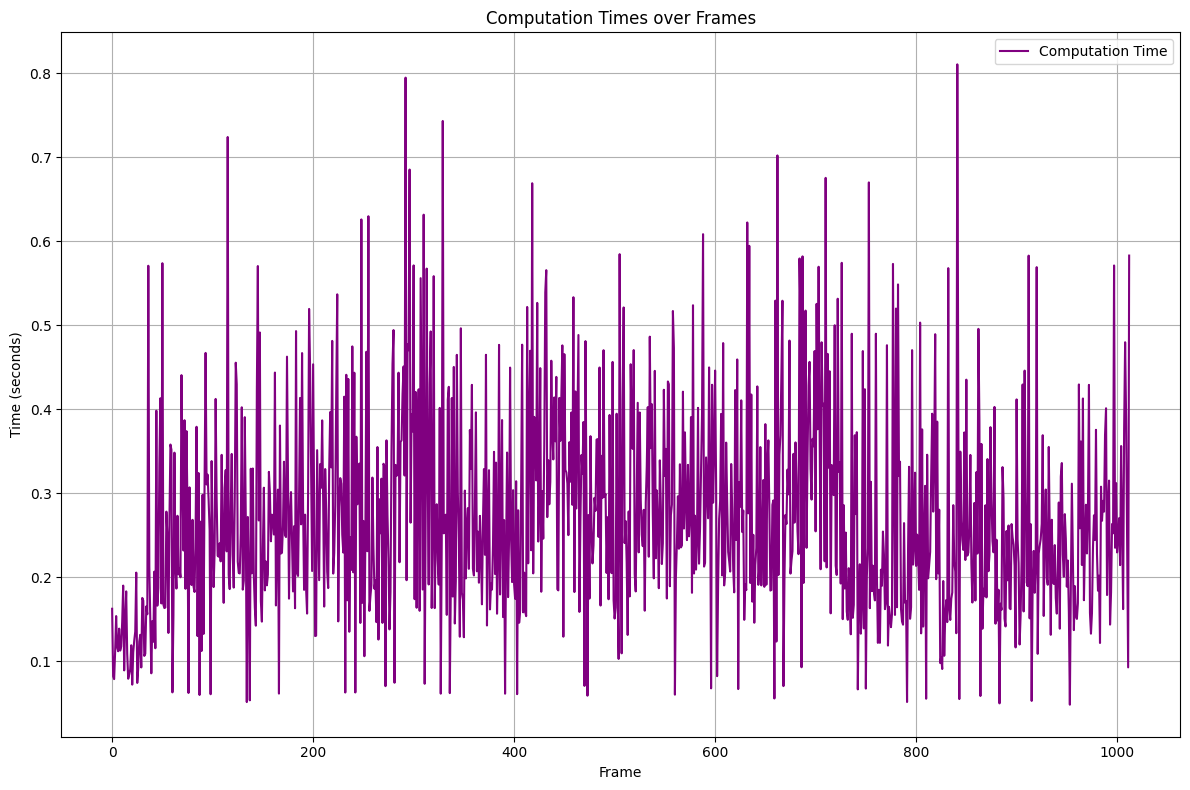

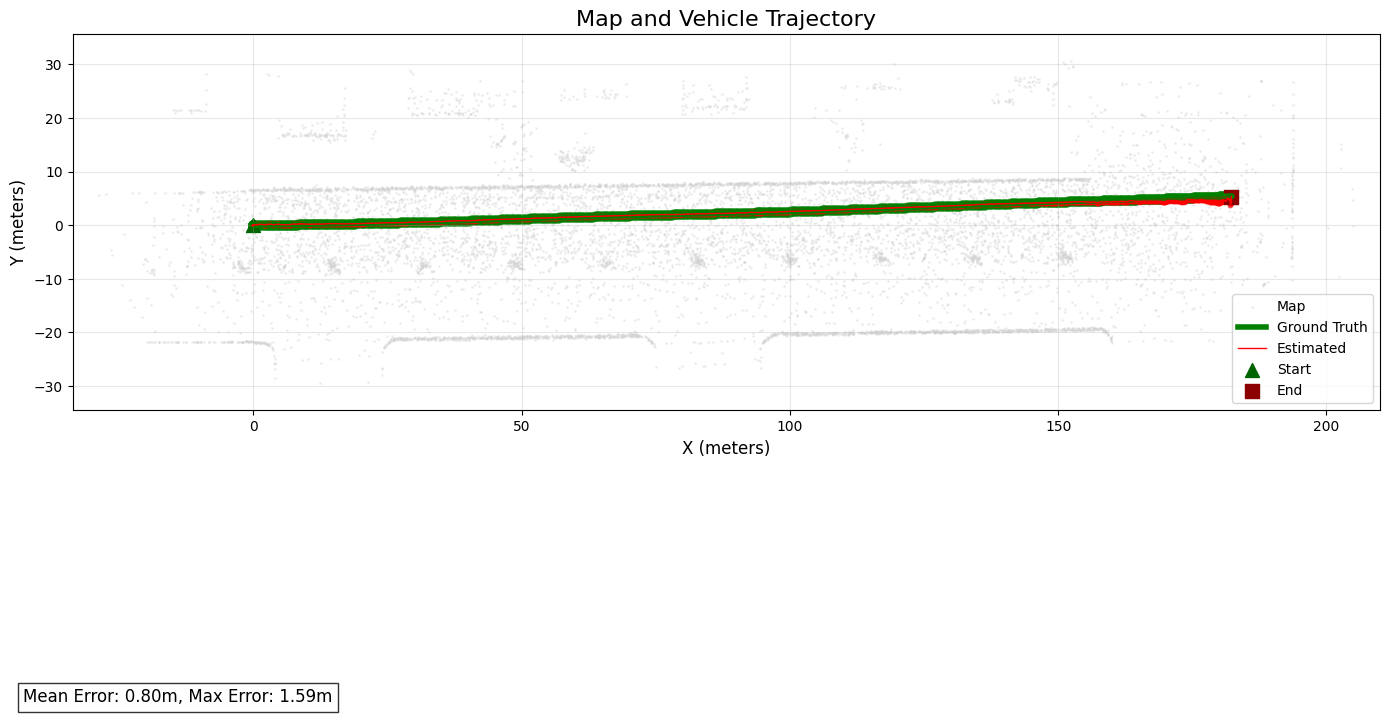

In [26]:
plot_results(results_icp)

## NDT

### Parameter Tuning (manual)

Here we visualize the effect of certain NDT parameters on the point cloud, just to do some sanity checking and better understand their effects on the algorithm and what it sees

In [28]:
from ipywidgets import FloatSlider, IntSlider, VBox, HBox, Label, Layout
from IPython.display import display

def update_plots(i, zmin, zmax, voxel_size, r):
    """Update all plots with the given parameters"""
    plt.close('all')  # Close any existing plots
    fig, ax = plt.subplots(3, 2, figsize=(12, 8))
    
    # Get the current frame
    pcd, _, _ = dataset[i]
    pcd_voxel, _ = downsample_voxel(pcd, voxel_size)
    
    # Filter out points with z within range
    zlims = [zmin, zmax]
    pcd_voxel_boundaries = boundaries(pcd_voxel, r, zlims=zlims)
    
    map_pcd = pcd_from_path(MAP_PATH)
    map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size)
    map_pcd_voxel_boundaries = boundaries(map_pcd_voxel, r, zlims=zlims)
    
    # Plotting the point clouds with titles
    plot_pcd(ax[0, 0], pcd, s=0.1)
    ax[0, 0].set_title('Original Point Cloud')
    
    plot_pcd(ax[1, 0], pcd_voxel, s=0.1)
    ax[1, 0].set_title('Voxelized Point Cloud')
    
    plot_pcd(ax[2, 0], pcd_voxel_boundaries, s=0.1)
    ax[2, 0].set_title('Filtered Point Cloud Boundaries')
    
    plot_pcd(ax[0, 1], map_pcd, s=0.1)
    ax[0, 1].set_title('Map Point Cloud')
    
    plot_pcd(ax[1, 1], map_pcd_voxel, s=0.1)
    ax[1, 1].set_title('Map Voxelized Point Cloud')
    
    plot_pcd(ax[2, 1], map_pcd_voxel_boundaries, s=0.1)
    ax[2, 1].set_title('Map Filtered Point Cloud Boundaries')
    
    # Set common title with parameters
    fig.suptitle(f'Frame: {i}, Z-limits: [{zmin}, {zmax}], Voxel Size: {voxel_size}, Boundary Radius: {r}', 
                 fontsize=14)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle
    
    # Instead of plt.show(), the figure will be displayed automatically by interactive_output

# Create the interactive display
def create_interactive_display():
    # Create sliders with reasonable ranges
    frame_slider = IntSlider(
        value=426, 
        min=0, 
        max=len(dataset)-1, 
        step=1, 
        description='Frame:',
        layout=Layout(width='50%')
    )
    
    zmin_slider = FloatSlider(
        value=0, 
        min=-10, 
        max=2, 
        step=0.1, 
        description='Z min:',
        layout=Layout(width='50%')
    )
    
    zmax_slider = FloatSlider(
        value=7, 
        min=2, 
        max=10, 
        step=0.1, 
        description='Z max:',
        layout=Layout(width='50%')
    )
    
    voxel_slider = FloatSlider(
        value=0.25, 
        min=0.01, 
        max=1.0, 
        step=0.01, 
        description='Voxel Size:',
        layout=Layout(width='50%')
    )
    
    radius_slider = FloatSlider(
        value=2.5, 
        min=0.5, 
        max=10, 
        step=0.1, 
        description='Radius:',
        layout=Layout(width='50%')
    )
    
    # Create interactive output
    from ipywidgets import interactive_output
    
    out = interactive_output(
        update_plots, 
        {
            'i': frame_slider, 
            'zmin': zmin_slider, 
            'zmax': zmax_slider,
            'voxel_size': voxel_slider,
            'r': radius_slider
        }
    )
    
    # Create UI layout
    slider_box = VBox([
        frame_slider,
        HBox([zmin_slider, zmax_slider]),
        HBox([voxel_slider, radius_slider])
    ])
    
    # Display the UI
    display(VBox([slider_box, out]))

# Run the interactive display
create_interactive_display()

### Implementation

In [32]:
def run_ndt_tracking(dataset, map_pcd, params, run_id):
    """
    Run NDT-based tracking on a sequence of point clouds.
    
    Args:
        dataset: List of (point_cloud, position, orientation) tuples
        map_pcd: Point cloud of the map
        params: Dictionary containing parameters:
            - 'ndt_cell_size': Size of the cells in the NDT grid
            - 'ylim': Y-axis limits for the NDT
            - 'xlim': X-axis limits for the NDT
            - 'voxel_size_map': Voxel size for downsampling the map point cloud
            - 'voxel_size_scan': Voxel size for downsampling the scan point cloud
            - 'r_map': Radius for boundary detection in the map
            - 'r_scan': Radius for boundary detection in the scan
            - 'zlims': Z-axis limits for the point clouds
            - 'ndt_iterations': Maximum number of iterations for the NDT algorithm
            - 'frame_range': Tuple indicating the range of frames to process
        run_id: Integer ID for this run
    
    Returns:
        Dictionary containing tracking results
    """
    # Lists to track results
    gt_positions = []
    estimated_positions = []
    computation_times = []
    norm_errors = []
    lateral_errors = []
    yaw_errors = []
    terminated_early = False

    early_stopping = params['early_stopping'] if 'early_stopping' in params else True

    # Get the initial pose from ground truth to initialize
    init_pcd, init_pos, init_orientation = dataset[params['frame_range'][0]]
    yaw = init_orientation[2]
    current_pose = Pose(init_pos[0], init_pos[1], yaw)

    # Process frames
    num_frames = min(len(dataset), params['frame_range'][1])
    pbar = tqdm(range(params['frame_range'][0], num_frames), 
                desc=f"Run {run_id}: Processing frames", leave=True)

    # Create NDT object
    ndt = NDT(params['ndt_cell_size'], params['ndt_cell_size'], 
              ylim=params['ylim'], xlim=params['xlim'])
    map_pcd_voxel, _ = downsample_voxel(map_pcd, params['voxel_size_map'])
    map_pcd_voxel_boundaries = boundaries(map_pcd_voxel, params['r_map'], zlims=params['zlims'])
    ndt.set_input_cloud(map_pcd_voxel_boundaries)
    cumulative_error = 0
    max_error = 0

    for i in pbar:
        start_time = time.time()

        # Get the current frame
        pcd, gt_pos, gt_orientation = dataset[i]
        gt_positions.append(gt_pos)
        
        # Voxelize the point clouds to reduce complexity
        pcd_voxel, _ = downsample_voxel(pcd, params['voxel_size_scan'])
        pcd_voxel_boundaries = boundaries(pcd_voxel, params['r_scan'], zlims=params['zlims'])
 
        # Run NDT to align current scan with map
        pose, _ = ndt.align(pcd_voxel_boundaries, current_pose, 
                          max_iterations=params['ndt_iterations'], eps=0.001)
        
        # Create transformation matrix from NDT result
        estimated_position = np.array([pose.x, pose.y, 0.0])
        estimated_orientation = np.array([0.0, 0.0, pose.yaw])
        current_pose = pose
        
        # Store estimated position
        estimated_positions.append(estimated_position)
        
        # Compute error
        norm_error = np.linalg.norm(estimated_position - gt_pos)
        lateral_error, yaw_error = calc_error(gt_pos, gt_orientation, 
                                            estimated_position, estimated_orientation)
        norm_errors.append(norm_error)
        lateral_errors.append(lateral_error)
        yaw_errors.append(yaw_error)
        cumulative_error += lateral_error
        if lateral_error > max_error:
            max_error = lateral_error
        
        # Check if error exceeds threshold
        if lateral_error > 1.2 and early_stopping:
            terminated_early = True
            pbar.set_postfix({
                "Norm Error": f"{norm_error:.2f}m",
                "Lateral Error": f"{lateral_error:.2f}m",
                "Yaw Error": f"{yaw_error:.2f}deg",
                "Time": f"{execution_time:.2f}s",
                "Cumulative Error": f"{cumulative_error:.2f}m",
                "Max Error": f"{max_error:.2f}m",
                "Status": "Terminated Early"
            })
            break
        
        # Compute execution time
        execution_time = time.time() - start_time
        computation_times.append(execution_time)
        
        # Update progress bar with current error
        pbar.set_postfix({
            "Norm Error": f"{norm_error:.2f}m",
            "Lateral Error": f"{lateral_error:.2f}m",
            "Yaw Error": f"{yaw_error:.2f}deg",
            "Time": f"{execution_time:.2f}s",
            "Cumulative Error": f"{cumulative_error:.2f}m",
            "Max Error": f"{max_error:.2f}m"
        })

    return {
        'gt_positions': gt_positions,
        'estimated_positions': estimated_positions,
        'computation_times': computation_times,
        'lateral_errors': lateral_errors,
        'yaw_errors': yaw_errors,
        'norm_errors': norm_errors,
        'terminated_early': terminated_early
    }

In [33]:
# Old params
# params = {
#     'voxel_size_scan': 0.45,
#     'voxel_size_map': 0.45*4,
#     'frame_range': [0, 1200],
#     'ndt_cell_size': 5,
#     'ndt_iterations': 10,
#     'r_scan': 1.5,
#     'r_map': 3,
#     'zlims': [-1, 7],
#     'ylim': None,
#     'xlim': None,
#     'early_stopping': False
# }
# params = {
#     'voxel_size_scan': 0.35,
#     'voxel_size_map': 0.35*4,
#     'frame_range': [0, 1200],
#     'ndt_cell_size': 4,
#     'ndt_iterations': 10,
#     'r_scan': 1.5,
#     'r_map': 3,
#     'zlims': [-1, 7],
#     'ylim': None,
#     'xlim': None,
#     'early_stopping': False
# }

In [ ]:
params = {
    'voxel_size_scan': 0.25,
    'voxel_size_map': 0.5,
    'frame_range': [0, 1200],
    'ndt_cell_size': 4,
    'ndt_iterations': 10,
    'r_scan': 1.5,
    'r_map': 3,
    'zlims': [-1, 7],
    'ylim': None,
    'xlim': None,
    'early_stopping': False
}
results_ndt = run_ndt_tracking(dataset, map_pcd, params, None)

Run None: Processing frames:   0%|          | 0/1014 [00:00<?, ?it/s]

### Grid Search for parameters

Notable combinations:
- voxel_size_scan 0.25 and voxel_size_map *2 -> 1.9, 52 ce, 0.83 me
- voxel_size_scan 0.35 and voxel_size_map *2 -> 1.6, 44 ce, 0.96 me
- voxel_size_scan 0.5 and voxel_size_map *4 -> 0.8s, 52 ce, 1.04 me
- r_scan 1.5 and r_map *2

In [30]:
def run_parameter_search(dataset, map_pcd):
    # Define parameter ranges
    # param_grid = {
    #     'voxel_size_scan': [0.2, 0.35, 0.5],
    #     'voxel_size_map': [0.3, 0.5, 0.7],
    #     'ndt_cell_size': [1.0, 1.5, 2.0],
    #     'ndt_iterations': [5, 15, 30],
    #     'r_scan': [1.0, 1.5, 2.0],
    #     'r_map': [2.0, 3.0, 4.0],
    #     'zlim_min': [-2.0, -1.0, 0.0],  # Added new parameter
    #     'zlim_max': [5.0, 7.0, 9.0],    # Added new parameter
    # }
    param_grid = {
        'voxel_size_scan': [0.25],
        'voxel_size_map': [0.5],
        # 'voxel_size_map_factor': [1.8, 2.0, 2.2],
        'ndt_cell_size': [4],
        'ndt_iterations': [10],
        'r_scan': [1.5],
        'r_map': [3.0],
        # 'r_map_factor': [1.8, 2.0, 2.2],
        'zlim_min': [-1],
        'zlim_max': [7],
    }

    # Generate all parameter combinations
    param_combinations = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

    # create new folder under /grid_search/ using timestamp
    grid_search_dir = f'grid_search/{time.strftime("%Y%m%d_%H%M%S")}'
    os.makedirs(grid_search_dir, exist_ok=True)

    # create results file
    results_file = os.path.join(grid_search_dir, 'results.csv')
    if os.path.exists(results_file):
        os.remove(results_file)
    

    # Initialize run ID
    run_id = 0
    
    # Run grid search with progress bar
    for params in tqdm(param_combinations, desc="Running parameter search"):
        run_id += 1

        # voxel size map = voxel size scan
        if 'voxel_size_map_factor' in params:
            params['voxel_size_map'] = params['voxel_size_scan'] * params['voxel_size_map_factor']
        
        if 'voxel_size_map' not in params:
            params['voxel_size_map'] = params['voxel_size_scan']
        
        if 'r_map_factor' in params:
            params['r_map'] = params['r_scan'] * params['r_map_factor']
        
        if 'r_map' not in params:
            params['r_map'] = params['r_scan']
        
        # Add fixed parameters
        params['frame_range'] = [550, 650]
        params['zlims'] = [params['zlim_min'], params['zlim_max']]  # Changed to use the parameters
        params['ylim'] = None
        params['xlim'] = None
        
        try:
            # Run NDT tracking
            tracking_results = run_ndt_tracking(dataset, map_pcd, params, run_id)
            
            # Calculate metrics
            max_lateral_error = np.max(tracking_results['lateral_errors'])
            mean_lateral_error = np.mean(tracking_results['lateral_errors'])
            max_yaw_error = np.max(tracking_results['yaw_errors'])
            mean_yaw_error = np.mean(tracking_results['yaw_errors'])
            mean_computation_time = np.mean(tracking_results['computation_times'])
            
            # Create result dictionary
            result = {
                'run_id': run_id,
                **params,
                'max_lateral_error': max_lateral_error,
                'mean_lateral_error': mean_lateral_error,
                'max_yaw_error': max_yaw_error,
                'mean_yaw_error': mean_yaw_error,
                'mean_computation_time': mean_computation_time
            }
            
            # Convert to DataFrame and append to file
            result_df = pd.DataFrame([result])
            if os.path.exists(results_file):
                result_df.to_csv(results_file, mode='a', header=False, index=False)
            else:
                result_df.to_csv(results_file, index=False)
                
        except Exception as e:
            print(f"Error in run {run_id} with parameters {params}: {str(e)}")
            continue

    # Load and display final results
    try:
        results_df = pd.read_csv(results_file)
        if not results_df.empty:
            # Sort by max lateral error (primary metric)
            results_df = results_df.sort_values('max_lateral_error')

            # Display top 10 parameter combinations
            print("\nTop 10 parameter combinations:")
            print(results_df.head(10).to_string())

            # Plot results
            plt.figure(figsize=(15, 10))

            # Plot max lateral error vs mean computation time
            plt.subplot(2, 2, 1)
            plt.scatter(results_df['mean_computation_time'], results_df['max_lateral_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Max Lateral Error (m)')
            plt.title('Max Lateral Error vs Computation Time')
            plt.grid(True)

            # Plot mean lateral error vs mean computation time
            plt.subplot(2, 2, 2)
            plt.scatter(results_df['mean_computation_time'], results_df['mean_lateral_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Mean Lateral Error (m)')
            plt.title('Mean Lateral Error vs Computation Time')
            plt.grid(True)

            # Plot max yaw error vs mean computation time
            plt.subplot(2, 2, 3)
            plt.scatter(results_df['mean_computation_time'], results_df['max_yaw_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Max Yaw Error (deg)')
            plt.title('Max Yaw Error vs Computation Time')
            plt.grid(True)

            # Plot mean yaw error vs mean computation time
            plt.subplot(2, 2, 4)
            plt.scatter(results_df['mean_computation_time'], results_df['mean_yaw_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Mean Yaw Error (deg)')
            plt.title('Mean Yaw Error vs Computation Time')
            plt.grid(True)

            plt.tight_layout()
            plt.show()
        else:
            print("No valid results to display")
    except FileNotFoundError:
        print("No results file found")

    return results_df

### Analysis

In [ ]:
plot_results(results_ndt)